In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from scipy import stats
from scipy.interpolate import griddata
# import xesmf as xe
from pathlib import Path
import cartopy.crs as ccrs
import netCDF4  
import time
# import mpl_toolkits.basemap
# import pyresample 
import utils as u

In [2]:
month_list = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
season_list = ["DJF","MAM","JJA","SON"]

In [3]:
# Removed pixels on domain boundaries
k =15

In [4]:
domain_2 = 'GRf'

### MAR

In [5]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRf.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
dsF_lon=ds_grF.LON[k:-k,k:-k]
dsF_lat=ds_grF.LAT[k:-k,k:-k]
dsF_SH=ds_grF.SH[k:-k,k:-k]

In [6]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/GRf/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [7]:
variable='TTZ' 

fileNameF= variable+'_mon_MARv3.14_ER5_spin2_'+domain_2+'_2000-2023.nc'
dsF= xr.open_dataset(sourceData_1+fileNameF).isel(ZTQLEV=0).TTZ.load()

dsF = dsF.assign_coords(X=np.round(dsF.X.values))
dsF = dsF.assign_coords(Y=np.round(dsF.Y.values))
dsF = dsF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
dsF = dsF[:,k:-k,k:-k]

In [8]:
lat_min=dsF_lat.values.min()
lat_max=dsF_lat.values.max()

lon_min=dsF_lon.values.min()
lon_max=dsF_lon.values.max()

latlim_grF=slice(dsF_lat.values.min(),dsF_lat.values.max())
lonlim_grF=slice(dsF_lon.values.min(),dsF_lon.values.max())

print('Mera domain')
print('lon min',dsF_lon.values.min(),'lon max',dsF_lon.values.max())
print('lat min',dsF_lat.values.min(),'lat max',dsF_lat.values.max())

Mera domain
lon min 68.38813 lon max 76.27104
lat min 36.850964 lat max 40.733284


In [9]:
# # #MAR reggrided on ERA5-Land grid
dsF_grid_era5Land =  xr.open_dataset(sourceData_2+'mar/TTZ_mon_MARv3.14_ER5_spin2_'+domain_2+'_2000-2023_remap_era5-land.nc').isel(ZTQLEV=0).TTZ.load()
dsF_grid_era5Land = dsF_grid_era5Land.rename({'TIME': 'time'})
dsF_grid_era5Land = dsF_grid_era5Land.rename({'lon':'longitude','lat':'latitude'})
dsF_grid_era5Land = dsF_grid_era5Land.rename({'x':'lon','y':'lat'})

dsF_grid_era5Land = dsF_grid_era5Land.where((dsF_grid_era5Land.lat >= lat_min) & (dsF_grid_era5Land.lat <= lat_max), drop=True)
dsF_grid_era5Land = dsF_grid_era5Land.where((dsF_grid_era5Land.lon >= lon_min) & (dsF_grid_era5Land.lon <= lon_max), drop=True)

# # #MAR reggrided on ERA5 grid
dsF_grid_era5 =  xr.open_dataset(sourceData_2+'mar/TTZ_mon_MARv3.14_ER5_spin2_'+domain_2+'_2000-2023_remap_era5.nc').isel(ZTQLEV=0).TTZ.load()
dsF_grid_era5 = dsF_grid_era5.rename({'TIME': 'time'})
dsF_grid_era5 = dsF_grid_era5.rename({'lon':'longitude','lat':'latitude'})
dsF_grid_era5 = dsF_grid_era5.rename({'x':'lon','y':'lat'})

dsF_grid_era5 = dsF_grid_era5.where((dsF_grid_era5.lat >= lat_min) & (dsF_grid_era5.lat <= lat_max), drop=True)
dsF_grid_era5 = dsF_grid_era5.where((dsF_grid_era5.lon >= lon_min) & (dsF_grid_era5.lon <= lon_max), drop=True)


#MAR reggrided on CRU grid 
dsF_grid_cru =  xr.open_dataset(sourceData_2 +'mar/TTZ_mon_MARv3.14_ER5_spin2_'+domain_2+'_2000-2023_remap_cru.nc').isel(ZTQLEV=0).TTZ.load()
dsF_grid_cru = dsF_grid_cru.rename({'TIME': 'time'})
dsF_grid_cru = dsF_grid_cru.rename({'lon':'longitude','lat':'latitude'})
dsF_grid_cru = dsF_grid_cru.rename({'x':'lon','y':'lat'})

dsF_grid_cru = dsF_grid_cru.where((dsF_grid_cru.lat >= lat_min) & (dsF_grid_cru.lat <= lat_max), drop=True)
dsF_grid_cru = dsF_grid_cru.where((dsF_grid_cru.lon >= lon_min) & (dsF_grid_cru.lon <= lon_max), drop=True)

(288, 86, 134)


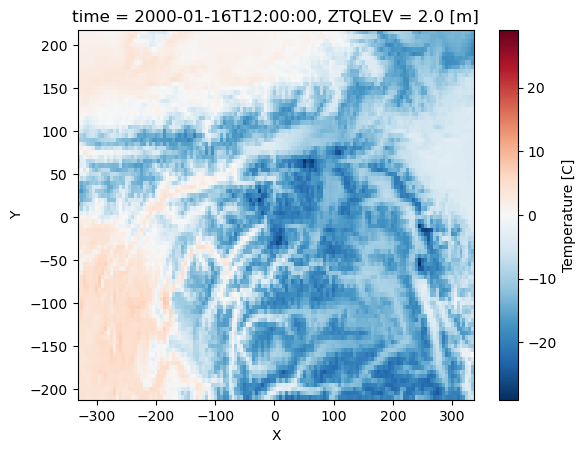

In [10]:
print(dsF.shape)
dsF[0,:,:].plot()

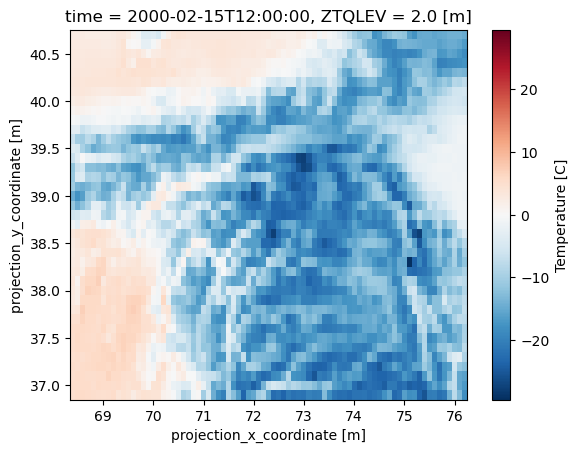

In [11]:
dsF_grid_era5Land.isel(time=1).plot()

(288, 15, 32)


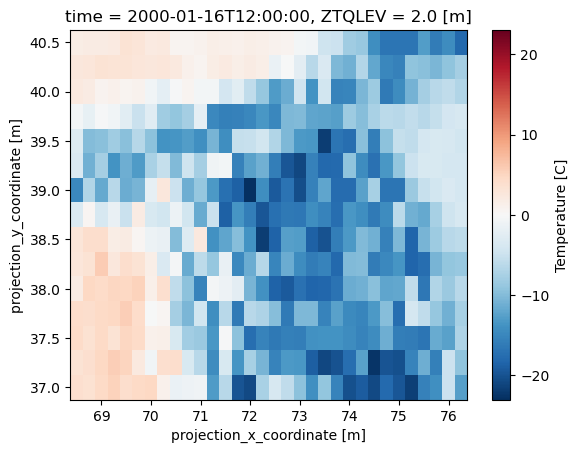

In [12]:
print(dsF_grid_era5.shape)
dsF_grid_era5[0,:,:].plot()

(288, 7, 16)


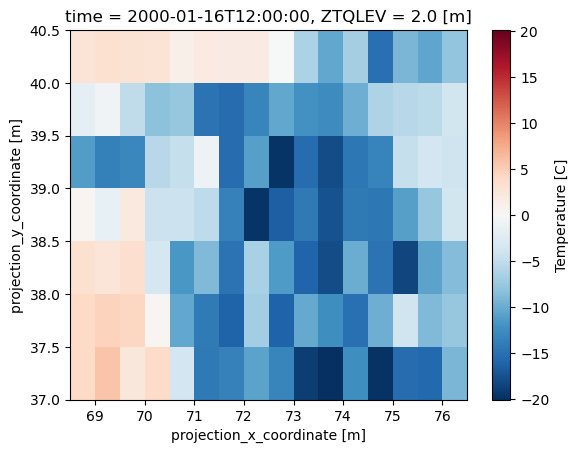

In [29]:
print(dsF_grid_cru.shape)
dsF_grid_cru[0,:,:].plot()

### ERA5-land

In [13]:
# ERA5-Land data coverage is only 2000 - 2023
folder_era5land = sourceData_2 + 'era5-land/'
tmp_era5land = xr.open_mfdataset(folder_era5land + 'era5_land_'+domain_2+'_t2m.nc').t2m.load()-273.15

tmp_era5land=tmp_era5land.rename({'latitude':'lat', 'longitude':'lon'})
tmp_era5land = tmp_era5land.rename({'valid_time': 'time'})

tmp_era5land = tmp_era5land.where((tmp_era5land.lat >= lat_min) & (tmp_era5land.lat <= lat_max), drop=True)
tmp_era5land = tmp_era5land.where((tmp_era5land.lon >= lon_min) & (tmp_era5land.lon <= lon_max), drop=True)

#ERA5-Land reggrided on MAR grid
tmp_era5land_reggrid = xr.open_mfdataset(folder_era5land + 'era5-land_t2m_remap_'+domain_2+'.nc').t2m.load()-273.15

tmp_era5land_reggrid = tmp_era5land_reggrid.rename({'x':'X','y':'Y'})
tmp_era5land_reggrid = tmp_era5land_reggrid.assign_coords(Y=np.round(tmp_era5land_reggrid.Y.values))
tmp_era5land_reggrid = tmp_era5land_reggrid.assign_coords(X=np.round(tmp_era5land_reggrid.X.values))
tmp_era5land_reggrid = tmp_era5land_reggrid.rename({'valid_time': 'time'})

tmp_era5land_reggrid = tmp_era5land_reggrid.where((tmp_era5land_reggrid.lat >= lat_min) & (tmp_era5land_reggrid.lat <= lat_max), drop=True)
tmp_era5land_reggrid = tmp_era5land_reggrid.where((tmp_era5land_reggrid.lon >= lon_min) & (tmp_era5land_reggrid.lon <= lon_max), drop=True)

(39, 79)


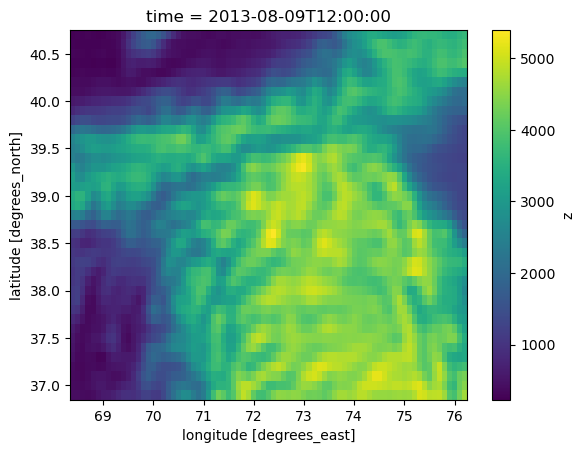

In [14]:
# ERA5-land orography
orog_era5land= xr.open_dataset(folder_era5land + 'geo.area-subset.42.78.36.66.nc').z.isel(time=0).load()/9.80665
orog_era5land=orog_era5land.rename({'latitude':'lat', 'longitude':'lon'})

orog_era5land = orog_era5land.where((orog_era5land.lat >= lat_min) & (orog_era5land.lat <= lat_max), drop=True)
orog_era5land = orog_era5land.where((orog_era5land.lon >= lon_min) & (orog_era5land.lon <= lon_max), drop=True)

print(orog_era5land.shape)
orog_era5land[:,:].plot()

(288, 39, 79)


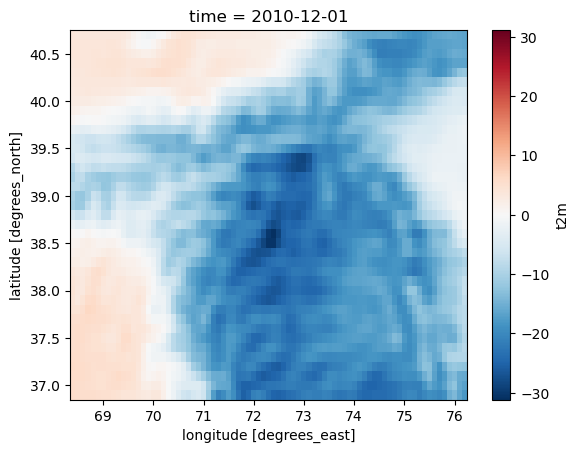

In [15]:
print(tmp_era5land.shape)
tmp_era5land[131,:,:].plot()

(288, 89, 140)


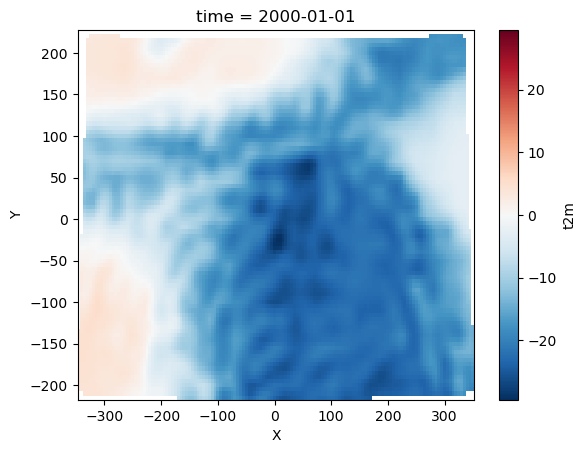

In [16]:
print(tmp_era5land_reggrid.shape)
tmp_era5land_reggrid[0,:,:].plot()

### ERA5

In [17]:
# ERA5 data coverage is only 2000 - 2023
folder_era5=sourceData_2+'era5/'
tmp_era5 = xr.open_mfdataset(folder_era5 + 'era5_'+domain_2+'_t2m.nc').t2m.load()-273.15
tmp_era5=tmp_era5.rename({'latitude':'lat', 'longitude':'lon', 'valid_time':'time'})

tmp_era5 = tmp_era5.where((tmp_era5.lat >= lat_min) & (tmp_era5.lat <= lat_max), drop=True)
tmp_era5 = tmp_era5.where((tmp_era5.lon >= lon_min) & (tmp_era5.lon <= lon_max), drop=True)

#ERA5-Land reggrided on MAR grid
tmp_era5_reggrid = xr.open_mfdataset(folder_era5 + 'era5_t2m_remap_'+domain_2+'.nc').t2m.load()-273.15

tmp_era5_reggrid = tmp_era5_reggrid.rename({'x':'X','y':'Y'})
tmp_era5_reggrid = tmp_era5_reggrid.assign_coords(Y=np.round(tmp_era5_reggrid.Y.values))
tmp_era5_reggrid = tmp_era5_reggrid.assign_coords(X=np.round(tmp_era5_reggrid.X.values))
tmp_era5_reggrid = tmp_era5_reggrid.rename({'valid_time': 'time'})

tmp_era5_reggrid = tmp_era5_reggrid.where((tmp_era5_reggrid.lat >= lat_min) & (tmp_era5_reggrid.lat <= lat_max), drop=True)
tmp_era5_reggrid = tmp_era5_reggrid.where((tmp_era5_reggrid.lon >= lon_min) & (tmp_era5_reggrid.lon <= lon_max), drop=True)

(15, 32)


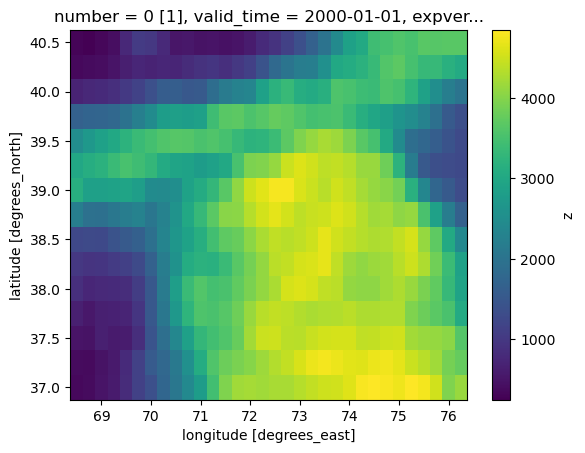

In [18]:
# ERA5 orography
orog_era5 = xr.open_mfdataset(folder_era5 + 'era5_'+domain_2+'_t2m.nc').z.isel(valid_time=0).load()/9.80665
orog_era5=orog_era5.rename({'latitude':'lat', 'longitude':'lon'})

orog_era5 = orog_era5.where((orog_era5.lat >= lat_min) & (orog_era5.lat <= lat_max), drop=True)
orog_era5 = orog_era5.where((orog_era5.lon >= lon_min) & (orog_era5.lon <= lon_max), drop=True)

print(orog_era5.shape)
orog_era5[:,:].plot()

(304, 15, 32)


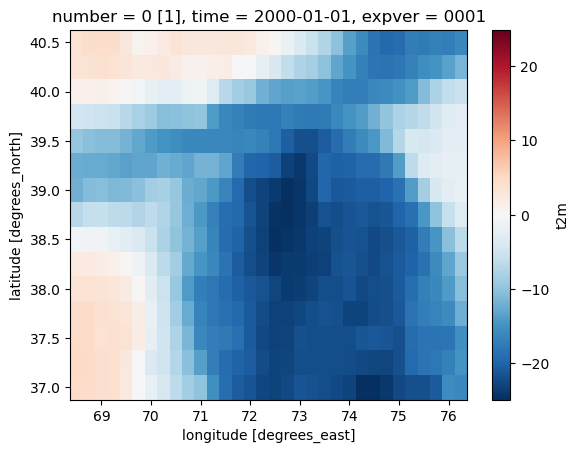

In [19]:
print(tmp_era5.shape)
tmp_era5[0,:,:].plot()

(304, 89, 140)


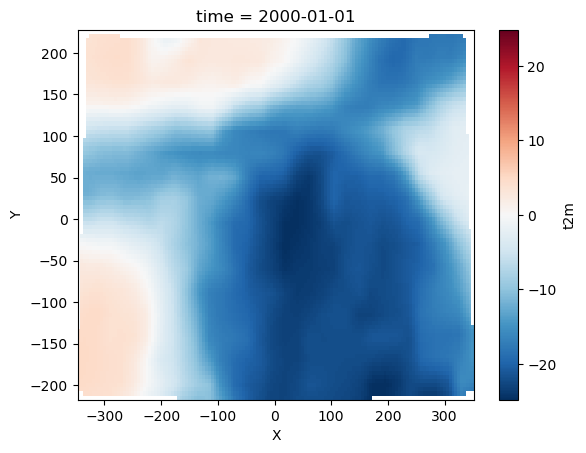

In [20]:
print(tmp_era5_reggrid.shape)
tmp_era5_reggrid[0,:,:].plot()

### CRU

In [21]:
# Could download latest version of CRU data
# 2021-2023 data missing

# folder_cru='/bettik/PROJECTS/pr-regional-climate/santolam/cru/'
tmp_cru = xr.open_mfdataset(sourceData_3 + 'cru/cru_ts4.05.1901.2020.tmp.dat_HMA.nc').sel(lat=latlim_grF,lon=lonlim_grF).tmp.load()
tmp_cru = tmp_cru.sel(time=tmp_cru.time[np.isin(tmp_cru.time.dt.year,[2000, 2020])])

tmp_cru = tmp_cru.where((tmp_cru.lat >= lat_min) & (tmp_cru.lat <= lat_max), drop=True)
tmp_cru = tmp_cru.where((tmp_cru.lon >= lon_min) & (tmp_cru.lon <= lon_max), drop=True)

# CRU reggrided on MAR grid
tmp_cru_reggrid = xr.open_mfdataset(sourceData_2 + 'cru/cru_ts4.05.1901.2020.tmp.dat_HMA_remap_'+ domain_2+'.nc').tmp.load()
tmp_cru_reggrid= tmp_cru_reggrid.sel(time=tmp_cru_reggrid.time[np.isin(tmp_cru_reggrid.time.dt.year,[2000, 2020])])

tmp_cru_reggrid = tmp_cru_reggrid.where((tmp_cru_reggrid.lat >= lat_min) & (tmp_cru_reggrid.lat <= lat_max), drop=True)
tmp_cru_reggrid = tmp_cru_reggrid.where((tmp_cru_reggrid.lon >= lon_min) & (tmp_cru_reggrid.lon <= lon_max), drop=True)

tmp_cru_reggrid = tmp_cru_reggrid.rename({'x':'X','y':'Y'})
tmp_cru_reggrid = tmp_cru_reggrid.assign_coords(Y=np.round(tmp_cru_reggrid.Y.values))
tmp_cru_reggrid = tmp_cru_reggrid.assign_coords(X=np.round(tmp_cru_reggrid.X.values))

(24, 7, 16)


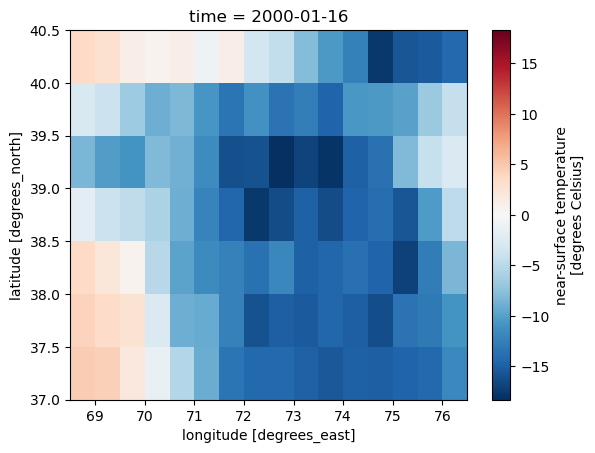

In [22]:
print(tmp_cru.shape)
tmp_cru[0,:,:].plot()

(24, 89, 140)


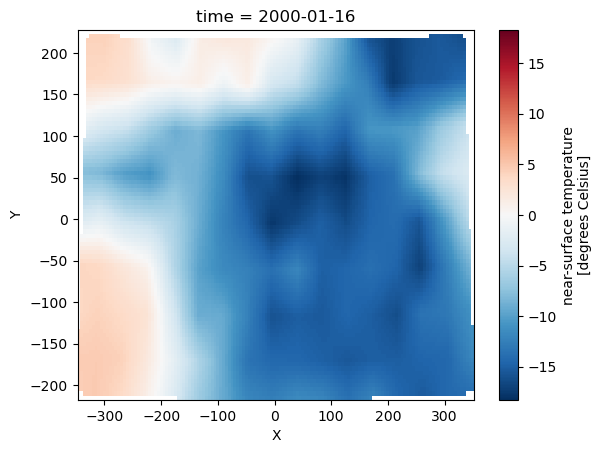

In [23]:
print(tmp_cru_reggrid.shape)
tmp_cru_reggrid[0,:,:].plot()

## 1. Seasonnal patterns: MAR vs ERA5-Land (interpolated on MAR grid)

/tmp/ipykernel_2149528/1888552775.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(dsF_lon, dsF_lat,
/tmp/ipykernel_2149528/1888552775.py:37: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(tmp_era5land_reggrid.lon, tmp_era5land_reggrid.lat,
/tmp/ipykernel_2149528/1888552775.py:48: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolorme

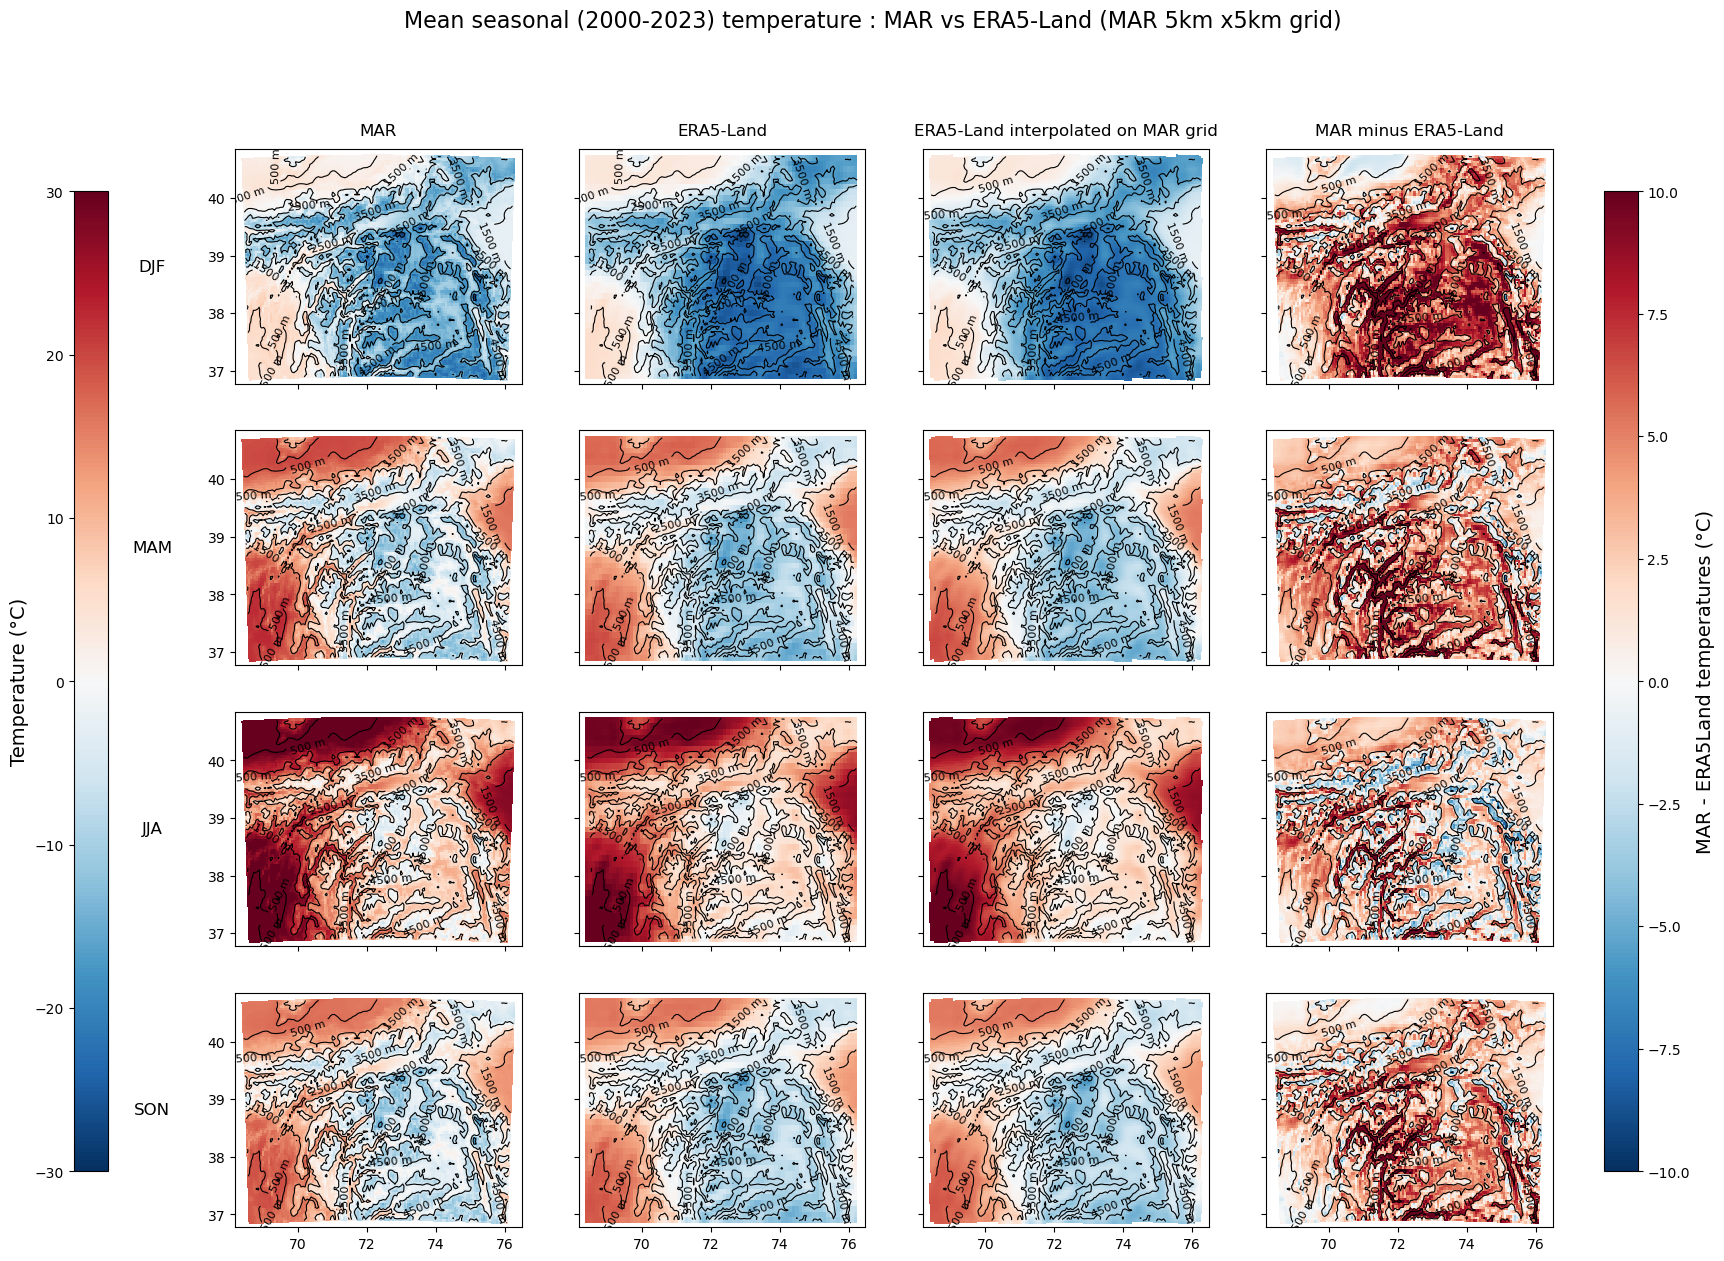

In [24]:
nrows = 4
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(17, 14)) 

j = k = l = q = 0
levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 

row_labels = season_list
col_labels = ['MAR', 'ERA5-Land', 'ERA5-Land interpolated on MAR grid', 'MAR minus ERA5-Land']

diff_meshes = []

# Paramètres communs aux colonnes 1 et 3
temp_cmap = 'RdBu_r'
temp_vmin = -30
temp_vmax = 30

for i, ax in enumerate(axes.flat):
    if (i) % 4 == 0 : 
        m = ax.pcolormesh(dsF_lon, dsF_lat,
                          dsF.groupby("time.season").mean('time').sel(season=season_list[j]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat,dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        j += 1

    elif (i-1) % 4 == 0 : 
        m = ax.pcolormesh(tmp_era5land.lon, tmp_era5land.lat,
                          tmp_era5land.groupby("time.season").mean('time').sel(season=season_list[q]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat,dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        q += 1
    
    elif (i-2) % 4 == 0 : 
        m = ax.pcolormesh(tmp_era5land_reggrid.lon, tmp_era5land_reggrid.lat,
                          tmp_era5land_reggrid.groupby("time.season").mean('time').sel(season=season_list[k]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat,dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        k += 1


    elif (i-3) % 4 == 0 : 
        diff = (dsF.groupby('time.season').mean('time').sel(season=season_list[l])
                - tmp_era5land_reggrid.groupby("time.season").mean('time').sel(season=season_list[l]))
        m = ax.pcolormesh(dsF_lon, dsF_lat, diff, 
                          cmap='RdBu_r', shading='auto', vmin=-10, vmax=10)
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')
        l += 1
        diff_meshes.append(m)
    
fig.suptitle('Mean seasonal (2000-2023) temperature : MAR vs ERA5-Land (MAR 5km x5km grid)', fontsize=16)

# Colorbar gauche 
cbar_ax_left = fig.add_axes([0.03, 0.15, 0.02, 0.7])
sm_left = ScalarMappable(cmap=temp_cmap, norm=plt.Normalize(vmin=temp_vmin, vmax=temp_vmax))
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='vertical')
cbar_left.ax.set_ylabel('Temperature (°C)', fontsize=14) 
cbar_left.ax.yaxis.set_ticks_position('left')
cbar_left.ax.yaxis.set_label_position('left')

# # Colorbar droite 
cbar_ax_right = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar_right = fig.colorbar(diff_meshes[0], cax=cbar_ax_right, orientation='vertical')
cbar_right.ax.set_ylabel('MAR - ERA5Land temperatures (°C)', fontsize=14) 

# Titres de colonnes
for ax, col in zip(axes[0], col_labels):
    ax.set_title(col, fontsize=12, pad=10)

# Labels de lignes (saisons)
for ax, row in zip(axes[:, 0], row_labels):
    ax.set_ylabel(row, fontsize=12, rotation=0, labelpad=40, va='center')

plt.savefig(folder_figure+'MAR_ERA5land_MARgrid_'+ domain_2+'.png',format='png', bbox_inches='tight')
plt.show()

## 2. Seasonnal patterns: MAR vs ERA5-Land (interpolated on ERA5-Land grid)

In [ ]:
nrows = 4
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(17, 14)) 

j = k = l = q = 0
levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 

row_labels = season_list
col_labels = ['MAR', 'MAR interpolated on ERA5-Land grid','ERA5-Land' ,'MAR minus ERA5-Land']

diff_meshes = []

# Paramètres communs aux colonnes 1 et 3
temp_cmap = 'RdBu_r'
temp_vmin = -30
temp_vmax = 30

for i, ax in enumerate(axes.flat):
    if (i) % 4 == 0 : 
        m = ax.pcolormesh(dsF_lon, dsF_lat,
                          dsF.groupby("time.season").mean('time').sel(season=season_list[j]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        j += 1
    

    
    elif (i-1) % 4 == 0 : 
        m = ax.pcolormesh(dsF_grid_era5Land.lon, dsF_grid_era5Land.lat,
                          dsF_grid_era5Land.groupby("time.season").mean('time').sel(season=season_list[k]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        k += 1

    elif (i-2) % 4 == 0 : 
        m = ax.pcolormesh(tmp_era5land.lon, tmp_era5land.lat,
                          tmp_era5land.groupby("time.season").mean('time').sel(season=season_list[q]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        q += 1
    
    elif (i-3) % 4 == 0 : 
        diff = (dsF_grid_era5Land.groupby('time.season').mean('time').sel(season=season_list[l])
                - tmp_era5land.groupby("time.season").mean('time').sel(season=season_list[l]))
        m = ax.pcolormesh(dsF_grid_era5Land.lon, dsF_grid_era5Land.lat, diff, 
                          cmap='RdBu_r', shading='auto', vmin=-10, vmax=10)
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')
        l += 1
        diff_meshes.append(m)
    
fig.suptitle('Mean seasonal (2000-2023) temperature : MAR vs ERA5-Land (ERA5-Land 0.1° x 0.1° grid)', fontsize=16)

# Colorbar gauche
cbar_ax_left = fig.add_axes([0.03, 0.15, 0.02, 0.7])
sm_left = ScalarMappable(cmap=temp_cmap, norm=plt.Normalize(vmin=temp_vmin, vmax=temp_vmax))
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='vertical')
cbar_left.ax.set_ylabel('Temperature (°C)', fontsize=14) 
cbar_left.ax.yaxis.set_ticks_position('left')
cbar_left.ax.yaxis.set_label_position('left')

# # Colorbar droite 
cbar_ax_right = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar_right = fig.colorbar(diff_meshes[0], cax=cbar_ax_right, orientation='vertical')
cbar_right.ax.set_ylabel('MAR - ERA5Land temperatures (°C)', fontsize=14) 

# Titres de colonnes
for ax, col in zip(axes[0], col_labels):
    ax.set_title(col, fontsize=12, pad=10)

# Labels de lignes (saisons)
for ax, row in zip(axes[:, 0], row_labels):
    ax.set_ylabel(row, fontsize=12, rotation=0, labelpad=40, va='center')

plt.savefig(folder_figure+'MAR_ERA5land_ERA5Landgrid_'+ domain_2+'.png',format='png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_2149528/3102845759.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(dsF_lon, dsF_lat,
/tmp/ipykernel_2149528/3102845759.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(dsF_lon, dsF_lat,
/tmp/ipykernel_2149528/3102845759.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m = ax.pcolormesh(dsF_lon, dsF_lat,
/tmp/ipykerne

## 3. Seasonnal patterns: MAR vs ERA5 (interpolated on MAR grid)

In [ ]:
nrows = 4
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(17, 14)) 

j = k = l = q = 0
levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 

row_labels = season_list
col_labels = ['MAR', 'ERA5' , 'ERA5 interpolated on MAR grid', 'MAR minus ERA5 ']

diff_meshes = []

# Paramètres communs aux colonnes 1 et 3
temp_cmap = 'RdBu_r'
temp_vmin = -30
temp_vmax = 30

for i, ax in enumerate(axes.flat):
    if (i) % 4 == 0 : 
        m = ax.pcolormesh(dsF_lon, dsF_lat,
                          dsF.groupby("time.season").mean('time').sel(season=season_list[j]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        j += 1
    
    
    elif (i-1) % 4 == 0 :
        m = ax.pcolormesh(tmp_era5.lon, tmp_era5.lat,
                          tmp_era5.groupby("time.season").mean('time').sel(season=season_list[q]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        q += 1
        
    
    elif (i-2) % 4 == 0 : 
        m = ax.pcolormesh(tmp_era5_reggrid.lon, tmp_era5_reggrid.lat,
                          tmp_era5_reggrid.groupby("time.season").mean('time').sel(season=season_list[k]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        k += 1


    elif (i-3) % 4 == 0 : 
        diff = (dsF.groupby('time.season').mean('time').sel(season=season_list[l])
                - tmp_era5_reggrid.groupby("time.season").mean('time').sel(season=season_list[l]))
        m = ax.pcolormesh(dsF_lon, dsF_lat, diff, 
                          cmap='RdBu_r', shading='auto', vmin=-10, vmax=10)
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')
        l += 1
        diff_meshes.append(m)
    
fig.suptitle('Mean seasonal (2000-2023) temperature : MAR vs ERA5 (MAR 5km x 5km grid)', fontsize=16)

# Colorbar gauche
cbar_ax_left = fig.add_axes([0.03, 0.15, 0.02, 0.7])
sm_left = ScalarMappable(cmap=temp_cmap, norm=plt.Normalize(vmin=temp_vmin, vmax=temp_vmax))
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='vertical')
cbar_left.ax.set_ylabel('Temperature (°C)', fontsize=14) 
cbar_left.ax.yaxis.set_ticks_position('left')
cbar_left.ax.yaxis.set_label_position('left')

# # Colorbar droite
cbar_ax_right = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar_right = fig.colorbar(diff_meshes[0], cax=cbar_ax_right, orientation='vertical')
cbar_right.ax.set_ylabel('MAR - ERA5 temperatures (°C)', fontsize=14) 

# Titres de colonnes
for ax, col in zip(axes[0], col_labels):
    ax.set_title(col, fontsize=12, pad=10)

# Labels de lignes (saisons)
for ax, row in zip(axes[:, 0], row_labels):
    ax.set_ylabel(row, fontsize=12, rotation=0, labelpad=40, va='center')

plt.savefig(folder_figure+'MAR_ERA5_MARgrid_'+ domain_2+'.png',format='png', bbox_inches='tight')
plt.show()

## 4. Seasonnal patterns: MAR vs ERA5 (interpolated on ERA5 grid)

In [ ]:
nrows = 4
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(17, 14)) 

j = k = l = q = 0
levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 

row_labels = season_list
col_labels = ['MAR', 'MAR interpolated on ERA5 grid', 'ERA5' , 'MAR minus ERA5']

diff_meshes = []

# Paramètres communs aux colonnes 1 et 3
temp_cmap = 'RdBu_r'
temp_vmin = -30
temp_vmax = 30

for i, ax in enumerate(axes.flat):
    if (i) % 4 == 0 : 
        m = ax.pcolormesh(dsF_lon, dsF_lat,
                          dsF.groupby("time.season").mean('time').sel(season=season_list[j]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        j += 1
    
    
    elif (i-1) % 4 == 0 : 
        m = ax.pcolormesh(dsF_grid_era5.lon, dsF_grid_era5.lat,
                           dsF_grid_era5.groupby("time.season").mean('time').sel(season=season_list[k]), 
                           cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        k += 1

    elif (i-2) % 4 == 0 : 
        m = ax.pcolormesh(tmp_era5.lon, tmp_era5.lat,
                          tmp_era5.groupby("time.season").mean('time').sel(season=season_list[q]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)   
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        q += 1
        

    elif (i - 3) % 4 == 0 : 
        diff = (dsF_grid_era5.groupby('time.season').mean('time').sel(season=season_list[l])
                - tmp_era5.groupby("time.season").mean('time').sel(season=season_list[l]))
        m = ax.pcolormesh(tmp_era5.lon, tmp_era5.lat, diff, 
                           cmap='RdBu_r', shading='auto', vmin=-10, vmax=10)
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')
        l += 1
        diff_meshes.append(m)
    
fig.suptitle('Mean seasonal (2000-2023) temperature : MAR vs ERA5 (ERA5 31km x 31km grid)', fontsize=16)

# Colorbar gauche
cbar_ax_left = fig.add_axes([0.03, 0.15, 0.02, 0.7])
sm_left = ScalarMappable(cmap=temp_cmap, norm=plt.Normalize(vmin=temp_vmin, vmax=temp_vmax))
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='vertical')
cbar_left.ax.set_ylabel('Temperature (°C)', fontsize=14) 
cbar_left.ax.yaxis.set_ticks_position('left')
cbar_left.ax.yaxis.set_label_position('left')

# # Colorbar droite 
cbar_ax_right = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar_right = fig.colorbar(diff_meshes[0], cax=cbar_ax_right, orientation='vertical')
cbar_right.ax.set_ylabel('MAR - ERA5 temperatures (°C)', fontsize=14) 

# Titres de colonnes
for ax, col in zip(axes[0], col_labels):
    ax.set_title(col, fontsize=12, pad=10)

# Labels de lignes (saisons)
for ax, row in zip(axes[:, 0], row_labels):
    ax.set_ylabel(row, fontsize=12, rotation=0, labelpad=40, va='center')

plt.savefig(folder_figure+'MAR_ERA5_ERA5grid_'+ domain_2+'.png',format='png', bbox_inches='tight')
plt.show()

## 5. Seasonnal differences : MAR vs CRU (interpolated on MAR grid)

In [ ]:
nrows = 4
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(17, 14)) 

j = k = l = q = 0
levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 

row_labels = season_list
col_labels = ['MAR','CRU', 'CRU interpolated on MAR grid', 'MAR minus CRU']

diff_meshes = []

temp_cmap = 'RdBu_r'
temp_vmin = -30
temp_vmax = 30

for i, ax in enumerate(axes.flat):
    if (i) % 4 == 0 : 
        m = ax.pcolormesh(dsF_lon, dsF_lat,
                          dsF.sel(time=dsF.time[np.isin(dsF.time.dt.year, [2000,2020])]).groupby("time.season").mean('time').sel(season=season_list[j]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH,levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        j += 1
    
    
    elif (i-1) % 4 == 0 : 
        m = ax.pcolormesh(tmp_cru.lon, tmp_cru.lat,
                          tmp_cru.groupby("time.season").mean('time').sel(season=season_list[k]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        k += 1

    
    elif (i-2) % 4 == 0 : 
        m = ax.pcolormesh(tmp_cru_reggrid.lon, tmp_cru_reggrid.lat,
                          tmp_cru_reggrid.groupby("time.season").mean('time').sel(season=season_list[q]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        q += 1

    
    elif (i-3) % 4 == 0 : 
        diff = (dsF.sel(time=dsF.time[np.isin(dsF.time.dt.year, [2000,2020])]).groupby('time.season').mean('time').sel(season=season_list[l])
                - tmp_cru_reggrid.groupby("time.season").mean('time').sel(season=season_list[l]))
        m = ax.pcolormesh(dsF_lon, dsF_lat, diff, 
                          cmap='RdBu_r', shading='auto', vmin=-10, vmax=10)
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')
        l += 1
        diff_meshes.append(m)
    
fig.suptitle('Mean seasonal (2000-2020) temperature : MAR vs CRU (MAR 5km x 5km grid)', fontsize=16)

# Colorbar gauche
cbar_ax_left = fig.add_axes([0.03, 0.15, 0.02, 0.7])
sm_left = ScalarMappable(cmap=temp_cmap, norm=plt.Normalize(vmin=temp_vmin, vmax=temp_vmax))
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='vertical')
cbar_left.ax.set_ylabel('Temperature (°C)', fontsize=14) 
cbar_left.ax.yaxis.set_ticks_position('left')
cbar_left.ax.yaxis.set_label_position('left')

# # Colorbar droite 
cbar_ax_right = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar_right = fig.colorbar(diff_meshes[0], cax=cbar_ax_right, orientation='vertical')
cbar_right.ax.set_ylabel('MAR - CRU temperatures (°C)', fontsize=14) 

# Titres de colonnes
for ax, col in zip(axes[0], col_labels):
    ax.set_title(col, fontsize=12, pad=10)

# Labels de lignes (saisons)
for ax, row in zip(axes[:, 0], row_labels):
    ax.set_ylabel(row, fontsize=12, rotation=0, labelpad=40, va='center')

plt.savefig(folder_figure+'MAR_CRU_MARgrid_'+ domain_2+'.png',format='png', bbox_inches='tight')
plt.show()

## 6. Seasonnal differences : MAR vs CRU (interpolated on CRU grid)

In [ ]:
nrows = 4
ncols = 4

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(17, 14)) 

j = k = l = q = 0
levels = np.arange(500, 7500, 1000)  # Niveaux tous les 1000m 

row_labels = season_list
col_labels = ['MAR', 'MAR interpolated on CRU grid', 'CRU', 'MAR minus CRU']

diff_meshes = []

temp_cmap = 'RdBu_r'
temp_vmin = -30
temp_vmax = 30

for i, ax in enumerate(axes.flat):
    if (i) % 4 == 0 : 
        m = ax.pcolormesh(dsF_lon, dsF_lat,
                          dsF.sel(time=dsF.time[np.isin(dsF.time.dt.year, [2000,2020])]).groupby("time.season").mean('time').sel(season=season_list[j]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        j += 1
    
    elif (i-1) % 4 == 0 : 
        m = ax.pcolormesh(dsF_grid_cru.lon, dsF_grid_cru.lat,
                          dsF_grid_cru.groupby("time.season").mean('time').sel(season=season_list[q]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        q += 1
        
    elif (i-2) % 4 == 0 : 
        m = ax.pcolormesh(tmp_cru.lon, tmp_cru.lat,
                          tmp_cru.groupby("time.season").mean('time').sel(season=season_list[k]), 
                          cmap=temp_cmap, shading='auto', vmin=temp_vmin, vmax=temp_vmax)     
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')         
        k += 1
    
    elif (i-3) % 4 == 0 : 
        diff = (dsF_grid_cru.sel(time=dsF_grid_cru.time[np.isin(dsF.time.dt.year, [2000,2020])]).groupby('time.season').mean('time').sel(season=season_list[l])
                - tmp_cru.groupby("time.season").mean('time').sel(season=season_list[l]))
        m = ax.pcolormesh(tmp_cru.lon, tmp_cru.lat, diff, 
                          cmap='RdBu_r', shading='auto', vmin=-10, vmax=10)
        contours = ax.contour(dsF_lon, dsF_lat, dsF_SH, levels=levels, colors='black', linewidths=0.8)
        ax.clabel(contours, inline=True, fontsize=8, fmt='%d m')
        l += 1
        diff_meshes.append(m)
    
fig.suptitle('Mean seasonal (2000-2020) temperature : MAR vs CRU (CRU 0.5° x 0.5° grid)', fontsize=16)

# Colorbar gauche
cbar_ax_left = fig.add_axes([0.03, 0.15, 0.02, 0.7])
sm_left = ScalarMappable(cmap=temp_cmap, norm=plt.Normalize(vmin=temp_vmin, vmax=temp_vmax))
cbar_left = fig.colorbar(sm_left, cax=cbar_ax_left, orientation='vertical')
cbar_left.ax.set_ylabel('Temperature (°C)', fontsize=14) 
cbar_left.ax.yaxis.set_ticks_position('left')
cbar_left.ax.yaxis.set_label_position('left')

# # Colorbar droite 
cbar_ax_right = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar_right = fig.colorbar(diff_meshes[0], cax=cbar_ax_right, orientation='vertical')
cbar_right.ax.set_ylabel('MAR - CRU temperatures (°C)', fontsize=14) 

# Titres de colonnes
for ax, col in zip(axes[0], col_labels):
    ax.set_title(col, fontsize=12, pad=10)

# Labels de lignes (saisons)
for ax, row in zip(axes[:, 0], row_labels):
    ax.set_ylabel(row, fontsize=12, rotation=0, labelpad=40, va='center')

plt.savefig(folder_figure+'MAR_CRU_CRUgrid_'+ domain_2+'.png',format='png', bbox_inches='tight')
plt.show()

## 7. Seasonal Altitudinal Profiles of ERA5 Deviation from MAR (MAR Interpolated onto ERA5 grid)

In [ ]:
colorList=['red','orange','blue','brown']

In [ ]:
seasonList=['DJF','MAM','JJA','SON']

In [ ]:
###Bin elevation (interval 250 m)
elev_flat = dsF_SH.values.flatten()
elev_bins = np.arange(0, np.max(elev_flat) + 250, 250)
elev_bin_labels = (elev_bins[:-1] + elev_bins[1:]) / 2

elev_bin_labels_R=np.array([0, 125.,  375.,  625.,  875., 1125., 1375., 1625., 1875., 2125.,
       2375., 2625., 2875., 3125., 3375., 3625., 3875., 4125., 4375.,
       4625., 4875., 5125., 5375., 5625., 5875., 6125., 6375., 6625.,
       6875., 7125.])

In [ ]:
elev_flat_era5 = orog_era5.values.flatten()

In [ ]:
dslist_era5 = [dsF_grid_era5.groupby("time.season").mean('time').sel(season='DJF') - tmp_era5.groupby("time.season").mean('time').sel(season='DJF'),
           dsF_grid_era5.groupby("time.season").mean('time').sel(season='MAM') - tmp_era5.groupby("time.season").mean('time').sel(season='MAM'),
           dsF_grid_era5.groupby("time.season").mean('time').sel(season='JJA') - tmp_era5.groupby("time.season").mean('time').sel(season='JJA'),
           dsF_grid_era5.groupby("time.season").mean('time').sel(season='SON') - tmp_era5.groupby("time.season").mean('time').sel(season='SON')]

In [ ]:
mean_tmp_by_elev_List_era5=[]

for elem in dslist_era5:
    tmp_flat = elem.values.flatten()
    df = pd.DataFrame({'elevation': elev_flat_era5, 'tmp': tmp_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
    mean_tmp_by_elev_List_era5.append(mean_tmp_by_elev)    

fig=plt.figure(figsize=(8, 10))

for i in np.arange(0,len(dslist_era5[1:])+1,1):
                   
    plt.plot(mean_tmp_by_elev_List_era5[i].values,elev_bin_labels, marker='o',color=colorList[i-1],
         label=seasonList[i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.xlim([-8, 8])  
plt.xticks(np.arange(-7, 10, 2))
plt.ylabel('Elevation (m)')
plt.xlabel('Deviation from spin2 (°C)')
plt.title('ERA5 : deviation from MAR (MAR interpolated on ERA5 grid), ' + domain_2)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(folder_figure+'MAR_altitudinal_deviation_from_ERA5_'+ domain_2+'.png',format='png', bbox_inches='tight')
plt.show()

## 8. Seasonal Altitudinal Profiles of ERA5-Land Deviation from MAR (MAR Interpolated onto ERA5-Land grid)

In [ ]:
elev_flat_era5land = orog_era5land.values.flatten()

In [ ]:
dslist_era5land = [dsF_grid_era5Land.groupby("time.season").mean('time').sel(season='DJF') - tmp_era5land.groupby("time.season").mean('time').sel(season='DJF'),
           dsF_grid_era5Land.groupby("time.season").mean('time').sel(season='MAM') - tmp_era5land.groupby("time.season").mean('time').sel(season='MAM'),
           dsF_grid_era5Land.groupby("time.season").mean('time').sel(season='JJA') - tmp_era5land.groupby("time.season").mean('time').sel(season='JJA'),
           dsF_grid_era5Land.groupby("time.season").mean('time').sel(season='SON') - tmp_era5land.groupby("time.season").mean('time').sel(season='SON')]

In [ ]:
mean_tmp_by_elev_List_era5land=[]

for elem in dslist_era5land:
    tmp_flat = elem.values.flatten()
    df = pd.DataFrame({'elevation': elev_flat_era5land, 'tmp': tmp_flat})
    df['elev_bin'] = pd.cut(df['elevation'], bins=elev_bins, labels=elev_bin_labels)
    mean_tmp_by_elev = df.groupby('elev_bin')['tmp'].mean()
    mean_tmp_by_elev_List_era5land.append(mean_tmp_by_elev)    

fig=plt.figure(figsize=(8, 10))

for i in np.arange(0,len(dslist_era5land[1:])+1,1):
                   
    plt.plot(mean_tmp_by_elev_List_era5land[i].values,elev_bin_labels, marker='o',color=colorList[i-1],
         label=seasonList[i])
             
plt.yticks(ticks=elev_bin_labels)
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)

plt.xlim([-8, 8])  
plt.xticks(np.arange(-8, 10, 2))
plt.ylabel('Elevation (m)')
plt.xlabel('Deviation from spin2 (°C)')
plt.title('ERA5-Land : deviation from MAR (MAR interpolated on ERA5Land grid), ' + domain_2)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(folder_figure+'MAR_altitudinal_deviation_from_ERA5Land_'+ domain_2+'.png',format='png', bbox_inches='tight')
plt.show()